# Entrenamiento V3 - Dataset Unificado + Hyperparámetros Refinados

Este cuaderno utiliza el nuevo dataset unificado (`nueva dataset.con labels`) que combina:
1. Pothole600 (Imágenes + Máscaras)
2. Pothole Video (Frames extraídos + Máscaras)
3. YOLOv8 Dataset
4. MWPD Dataset

**Objetivo:** Mejorar F1 Score > 0.85 y mAP > 0.85.



In [8]:
import os
from ultralytics import YOLO
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



CUDA Available: True
GPU: NVIDIA GeForce RTX 3060 Ti
VRAM: 8.59 GB


In [9]:

PROJECT_NAME = 'Tesis_Potholes'
RUN_NAME = 'Entrenamiento_V3_Unified_Final'
DATA_YAML = r'C:\Users\Rayols\Desktop\dataset_unificado_final\data.yaml'

# Cargar Modelo Base (YOLO11 Large Segment)
model = YOLO('yolo11l-seg.pt')



## 1. Distribución del Dataset
Visualización de la cantidad de imágenes en Train y Validation.


In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

dataset_path = Path(r"C:\Users\Rayols\Desktop\dataset_unificado_final")
train_path = dataset_path / "train" / "images"
val_path = dataset_path / "valid" / "images"

n_train = len(list(train_path.glob('*'))) if train_path.exists() else 0
n_val = len(list(val_path.glob('*'))) if val_path.exists() else 0

print(f"Train Images: {n_train}")
print(f"Valid Images: {n_val}")

plt.figure(figsize=(6, 6))
plt.pie([n_train, n_val], labels=['Train', 'Validation'], autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title(f'Distribución del Dataset (Total: {n_train + n_val})')
plt.show()



Train Images: 4437
Valid Images: 1113


<Figure size 600x600 with 1 Axes>

## Configuración de Entrenamiento Optimizada (v3)


In [11]:

# Entrenar
results = model.train(
    data=DATA_YAML,
    
    # Duración y Paciencia
    epochs=300,
    patience=75,
    
    # Optimizador (Ajuste Fino)
    optimizer='AdamW',
    lr0=0.0005,    # Reducido para evitar divergencia
    lrf=0.01,      # Final LR = 0.0005 * 0.01
    
    # Augmentation
    mixup=0.15,
    copy_paste=0.3,
    degrees=15.0,
    shear=2.0,
    perspective=0.0005,
    flipud=0.0,    # Baches no suelen estar boca abajo
    fliplr=0.5,
    
    # Loss Weights & Segmentación
    overlap_mask=True,
    mask_ratio=4,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    
    # Hardware
    imgsz=640,
    batch=8,
    device=0,
    workers=8,
    
    # Output
    project=PROJECT_NAME,
    name=RUN_NAME,
    plots=True,
    save=True,
    exist_ok=True
)



New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.9.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Rayols\Desktop\dataset_unificado_final\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=F

## Análisis Completo de Resultados
Incluye:
1. Curvas de Entrenamiento (Losses & mAP).
2. F1 Score Máximo.
3. Matriz de Confusión Normalizada.
4. Ejemplos de Predicción.



 MEJOR EPOCA: 298
mAP50 (Mask):    0.8842
mAP50-95 (Mask): 0.5759
Precision (Mask): 0.8707
Recall (Mask):    0.8279
F1 Score (Mask):  0.8487
----------------------------------------


<Figure size 1800x1200 with 5 Axes>


Gráficas Oficiales de YOLO:
--- results.png ---


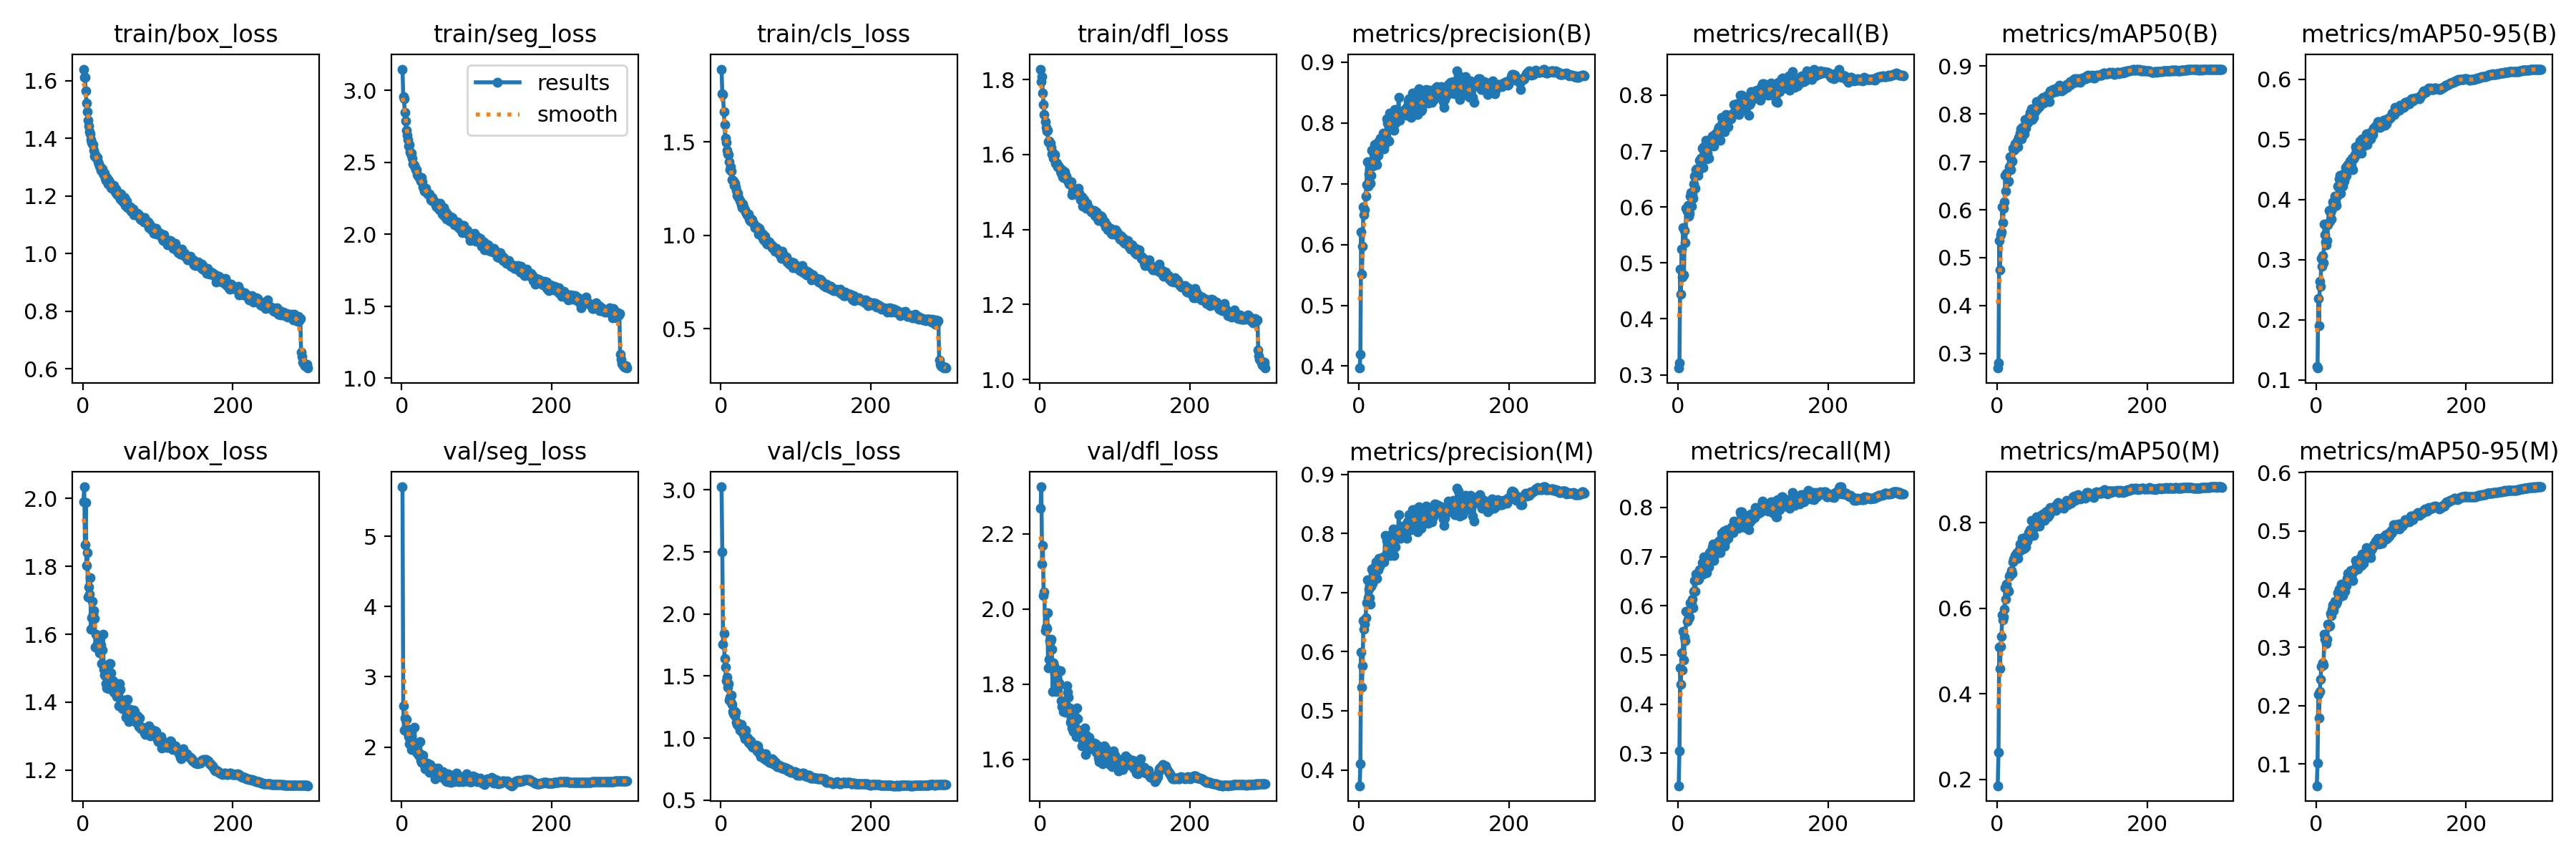

--- MaskP_curve.png ---


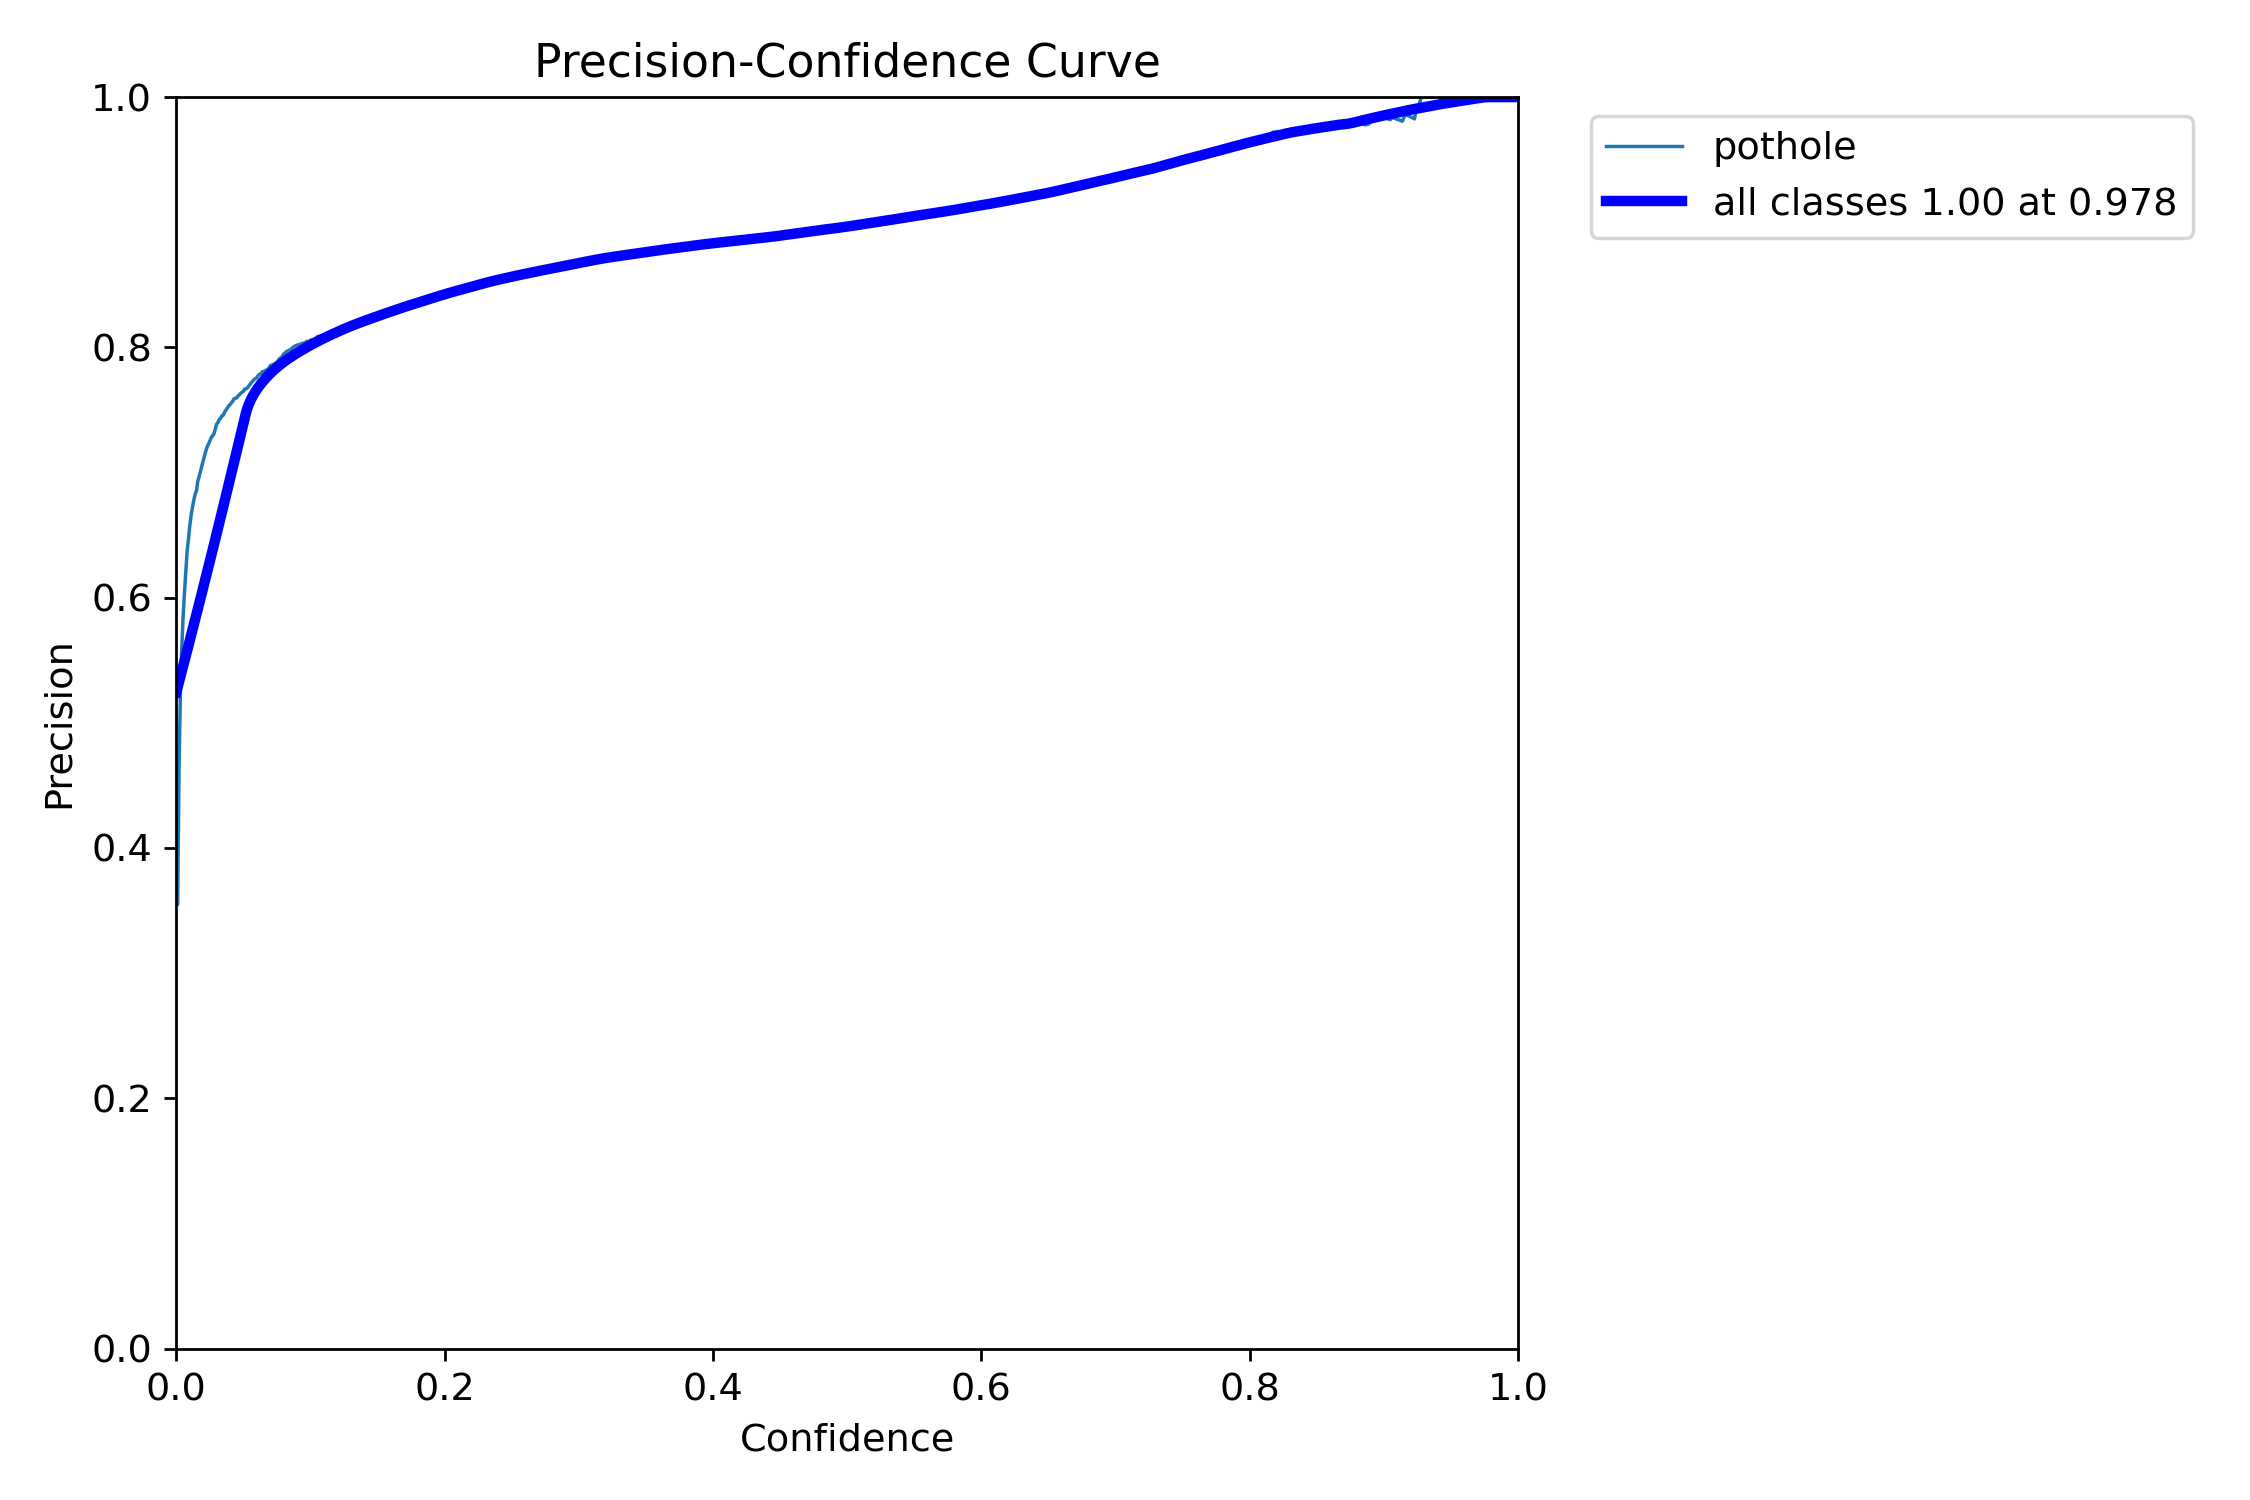

--- MaskR_curve.png ---


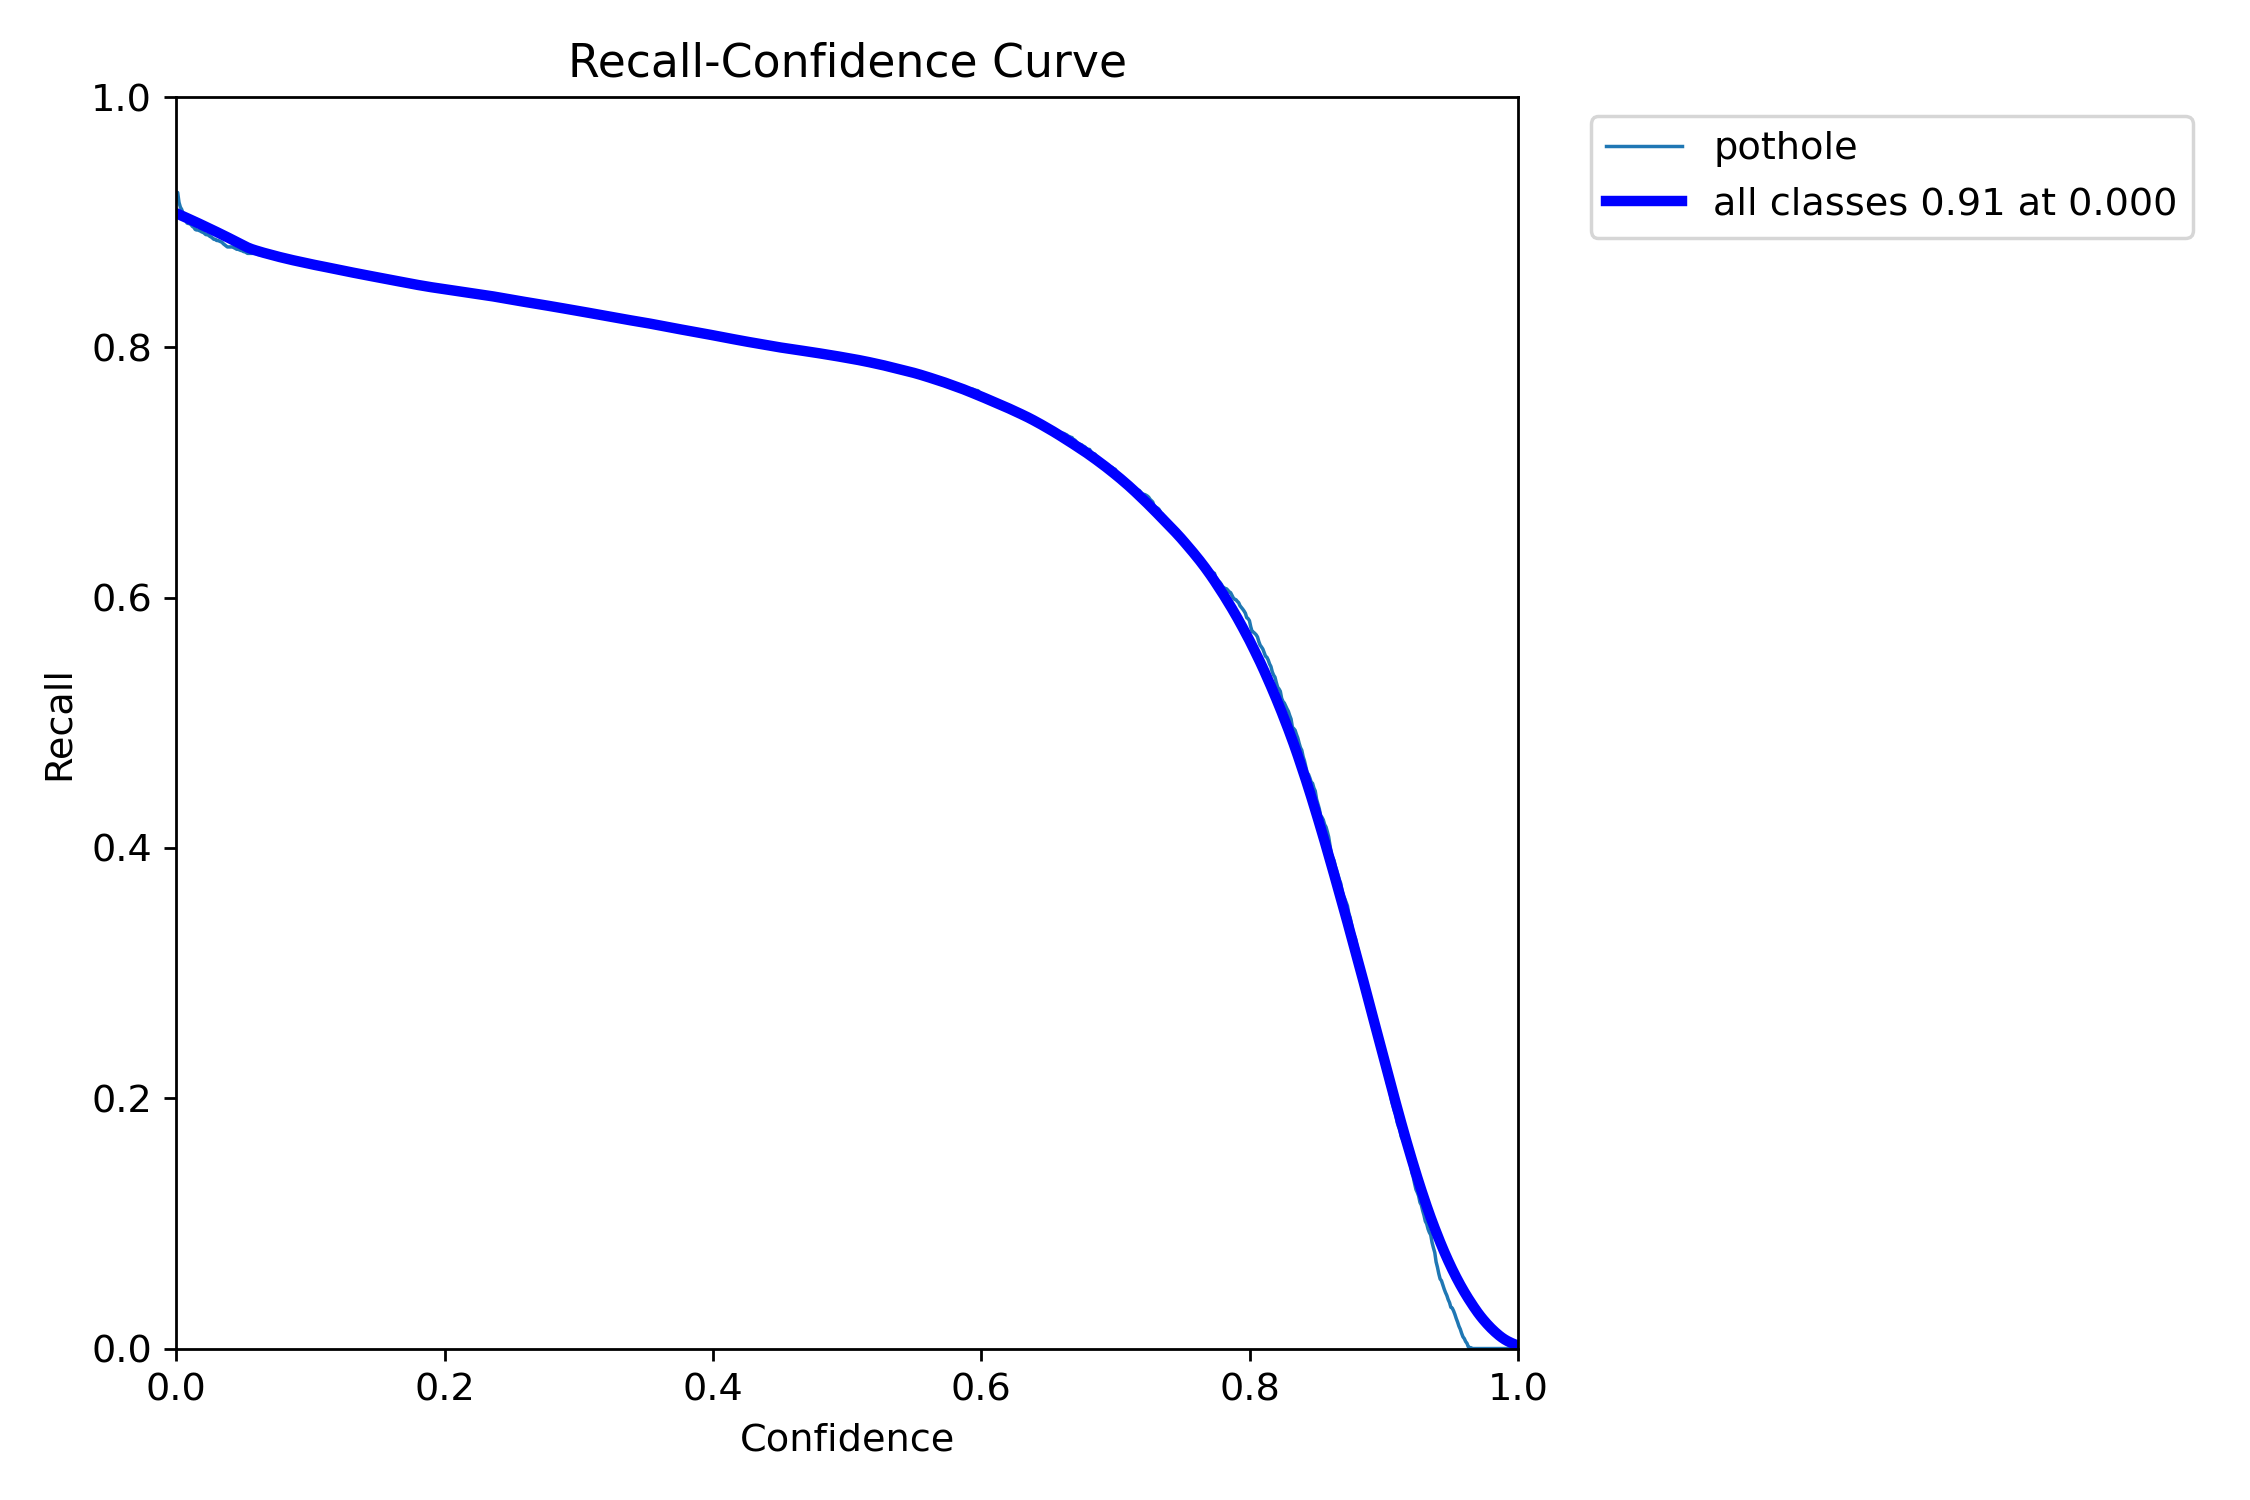

--- MaskPR_curve.png ---


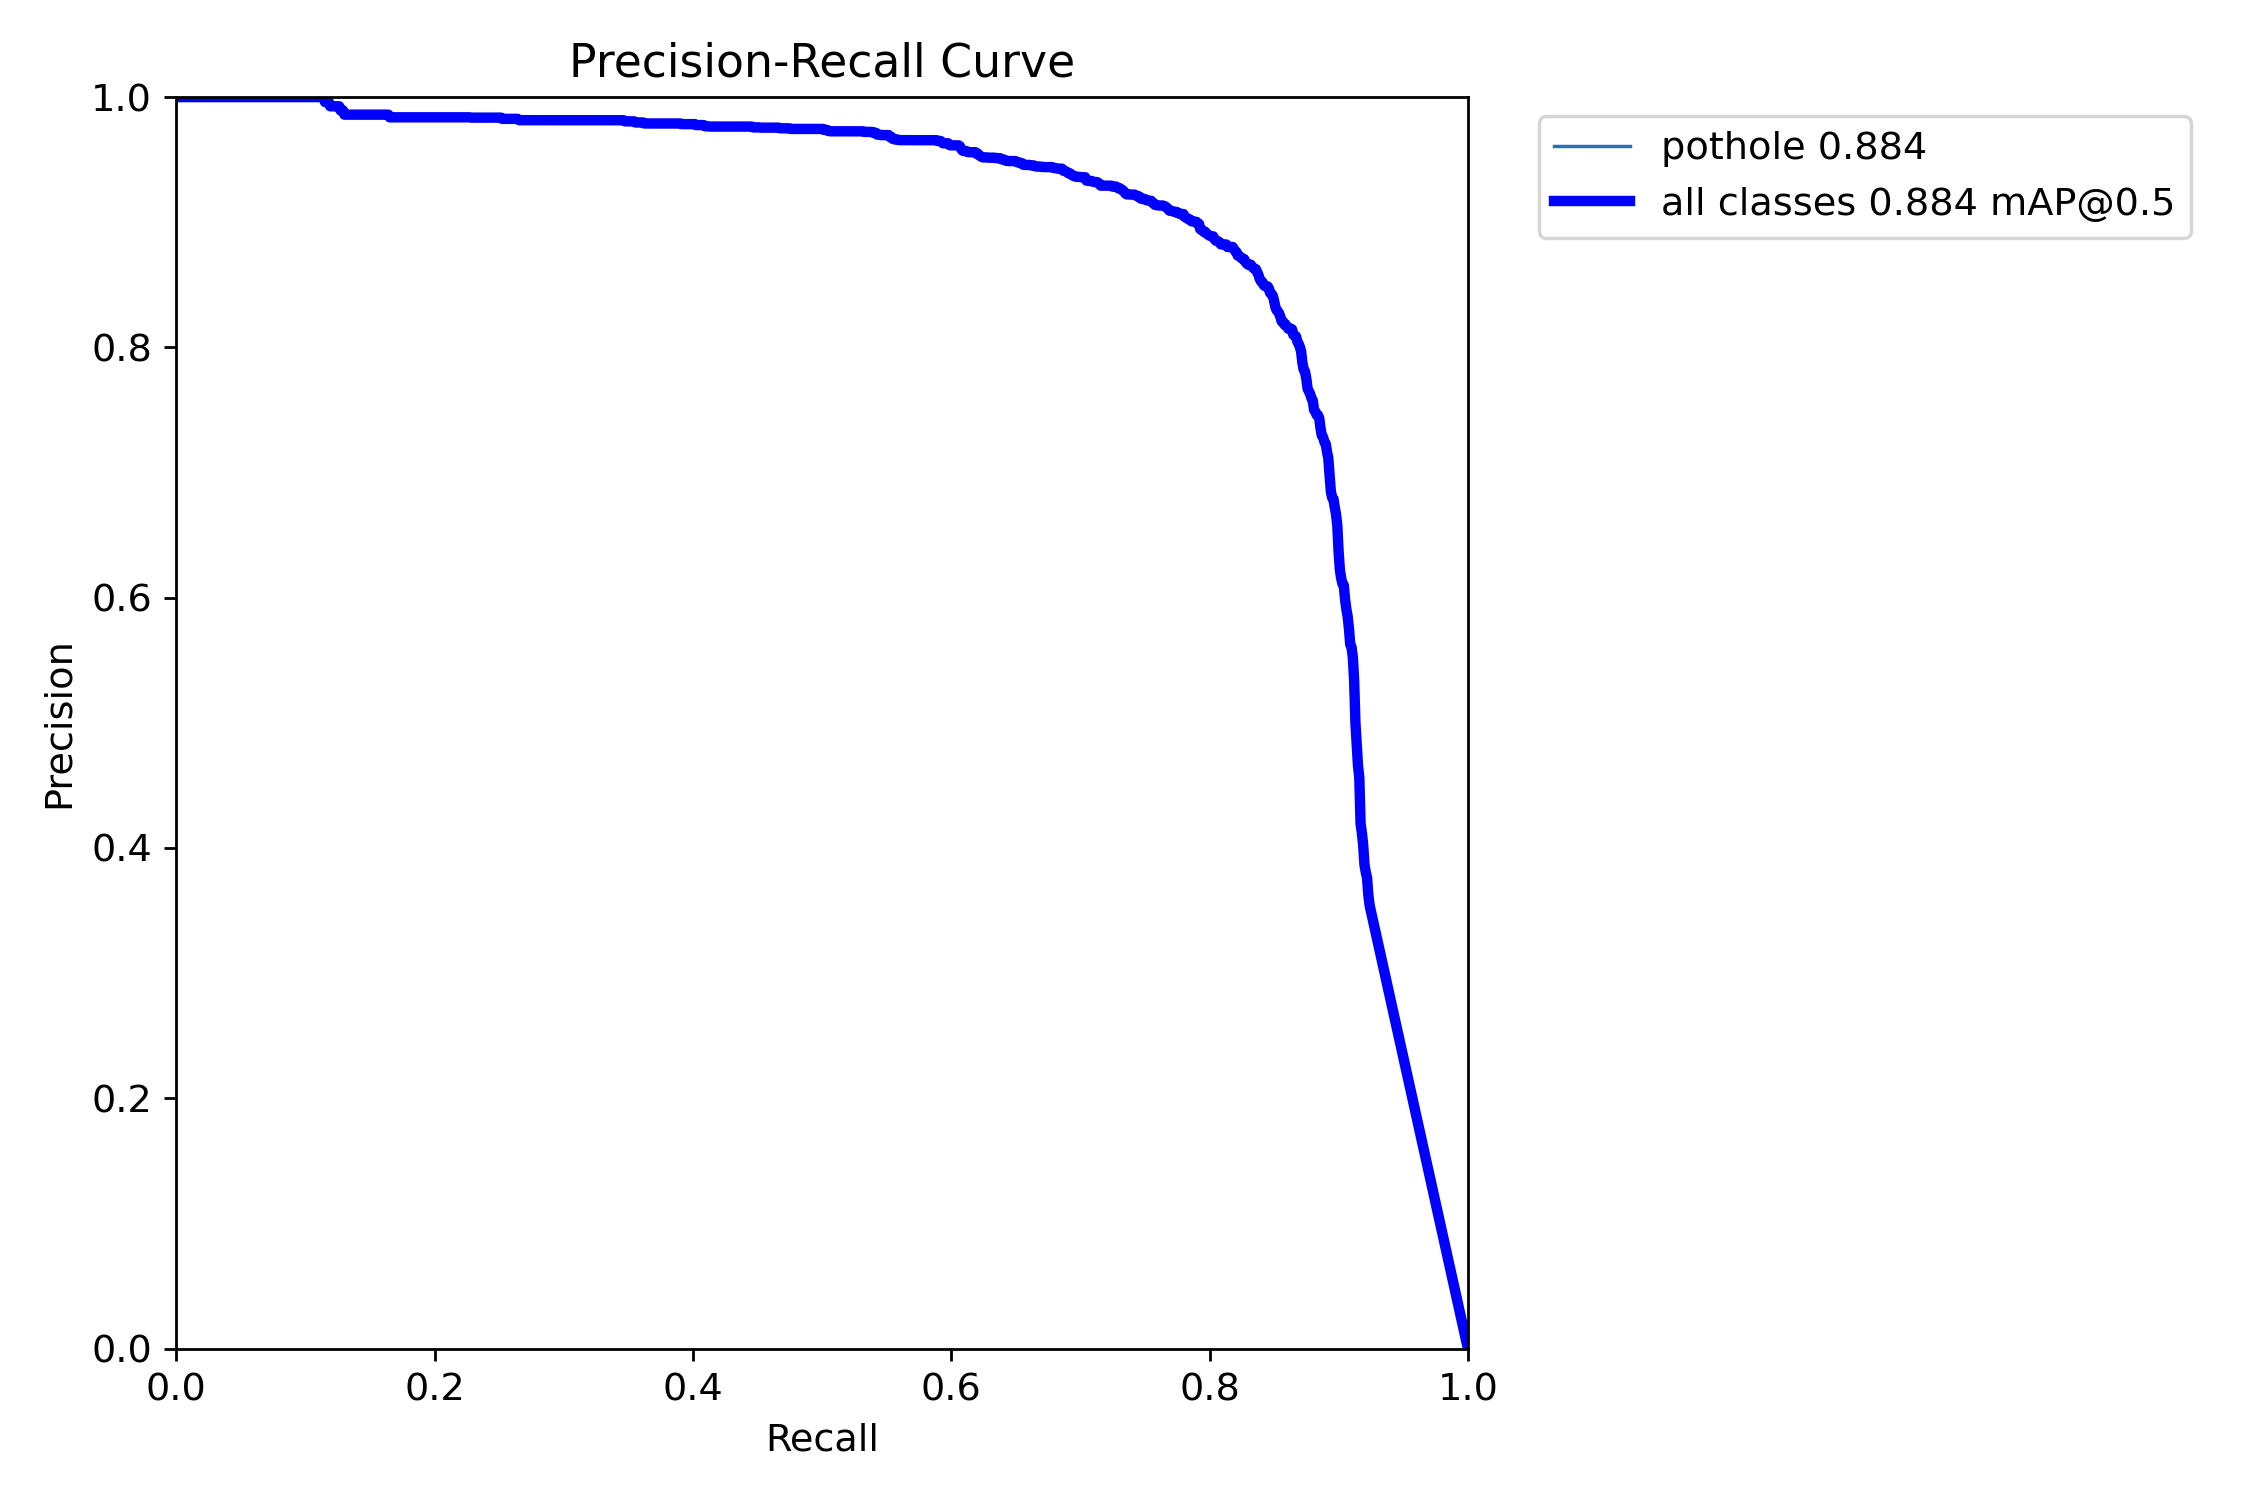

--- MaskF1_curve.png ---


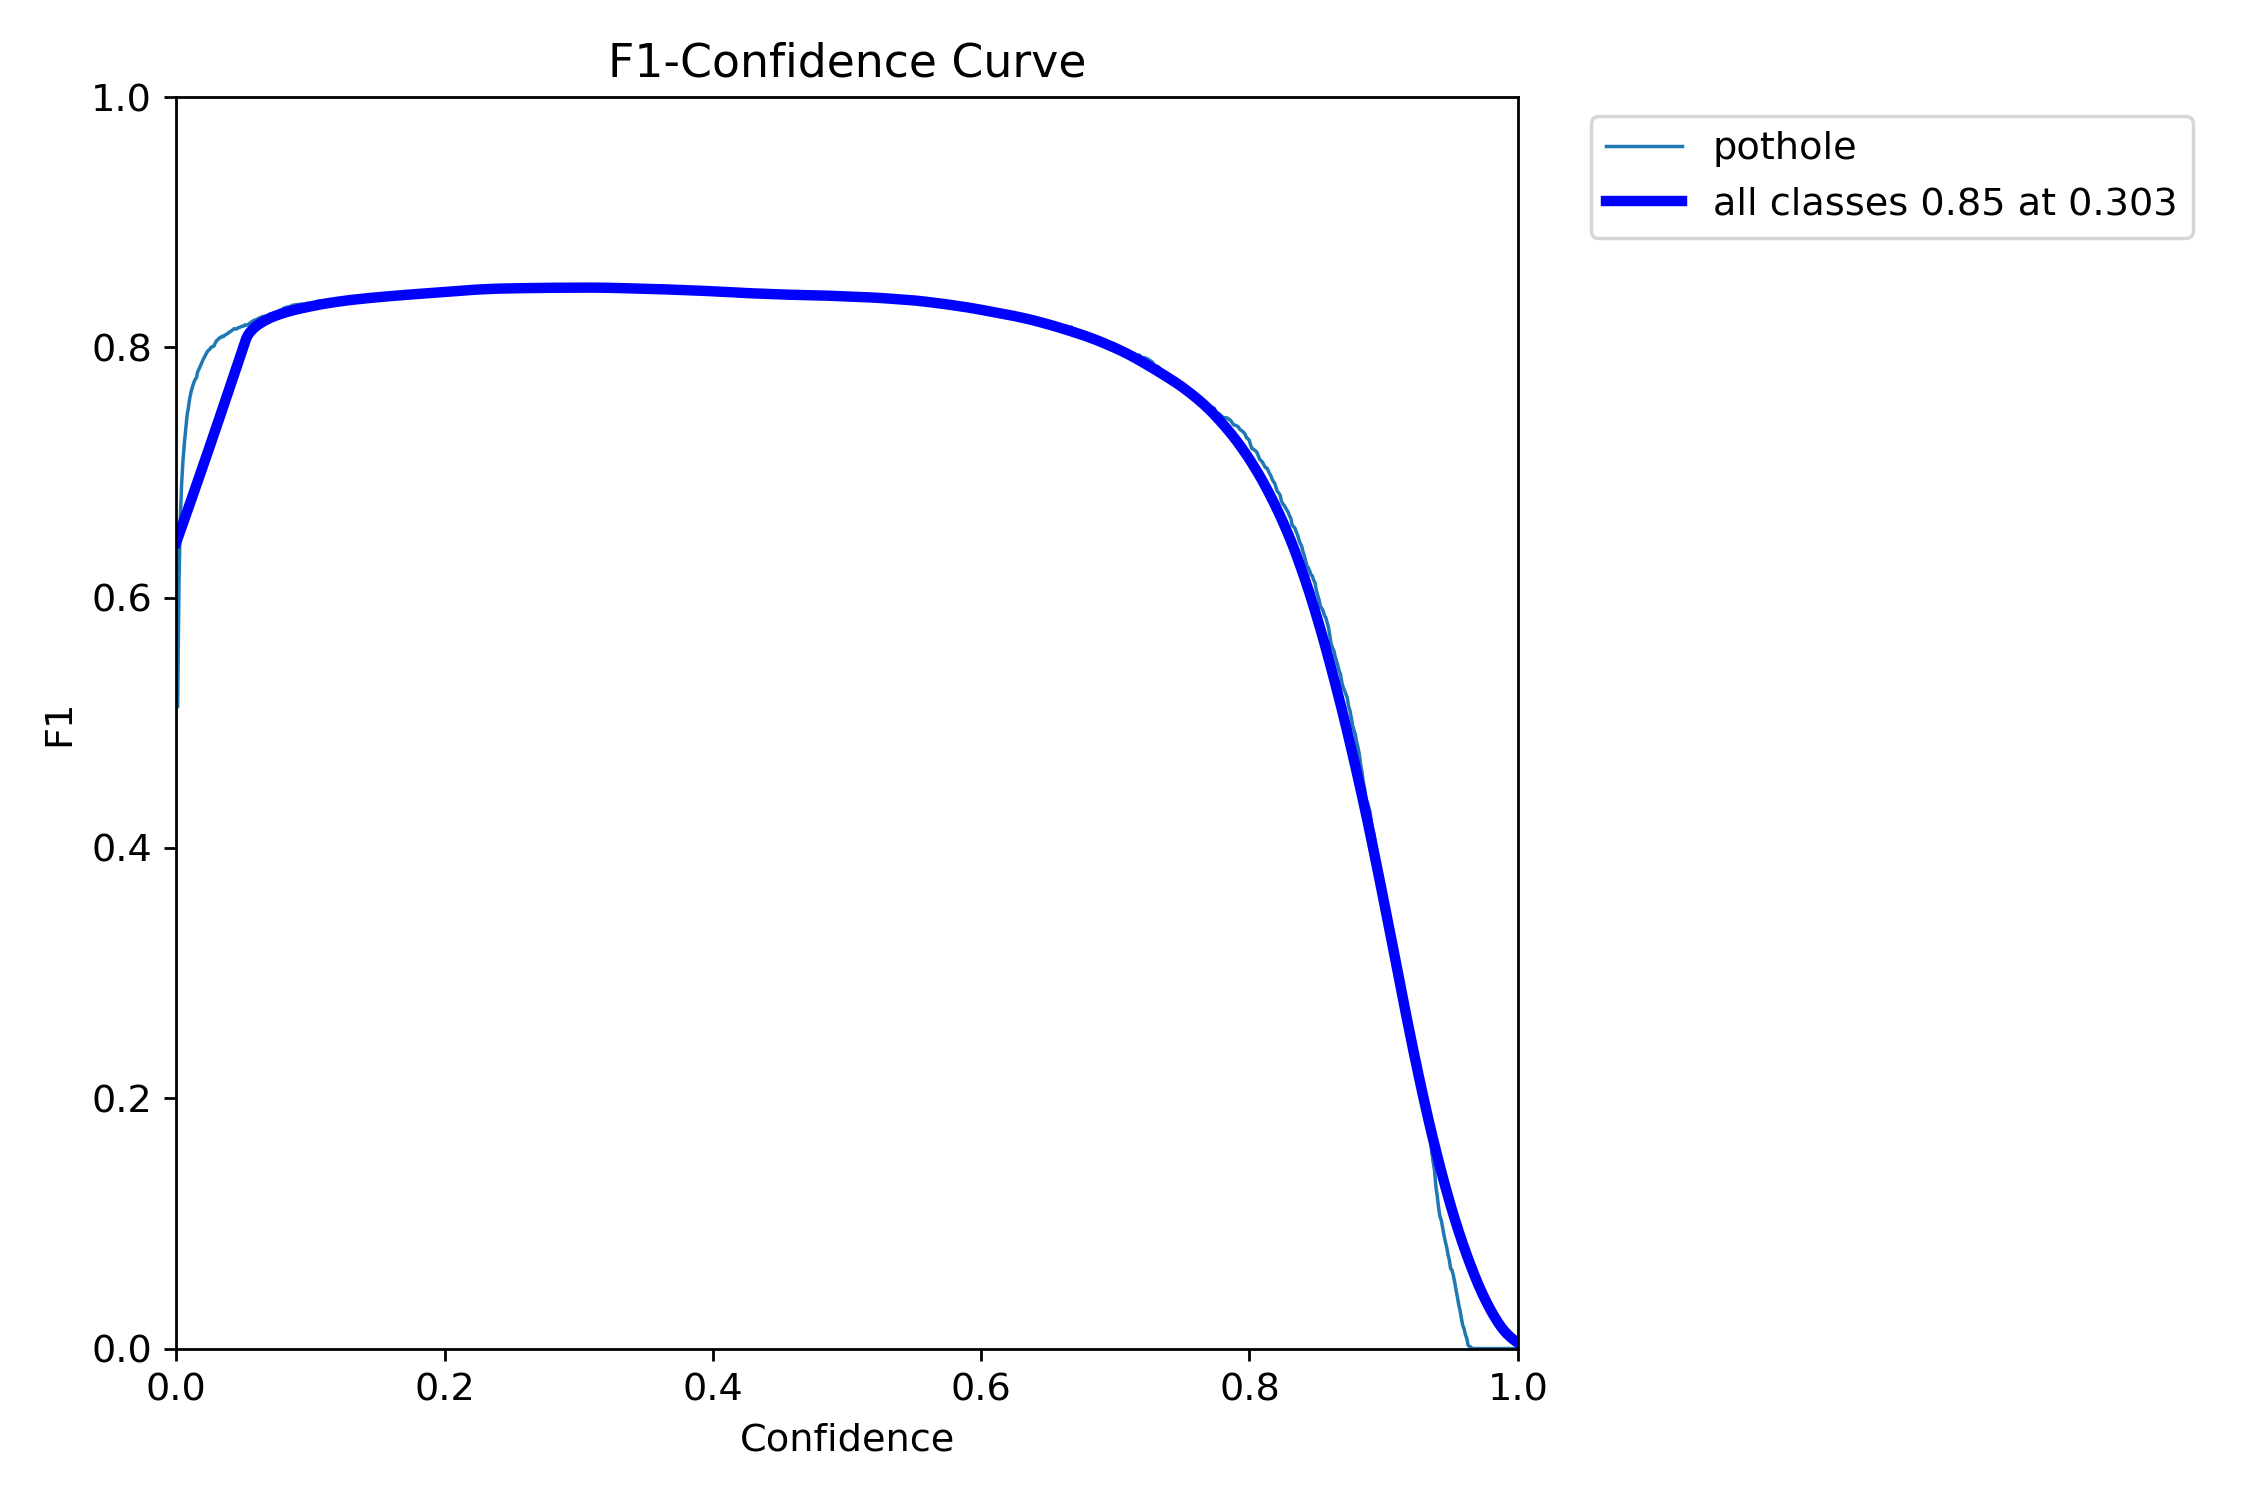

--- confusion_matrix_normalized.png ---


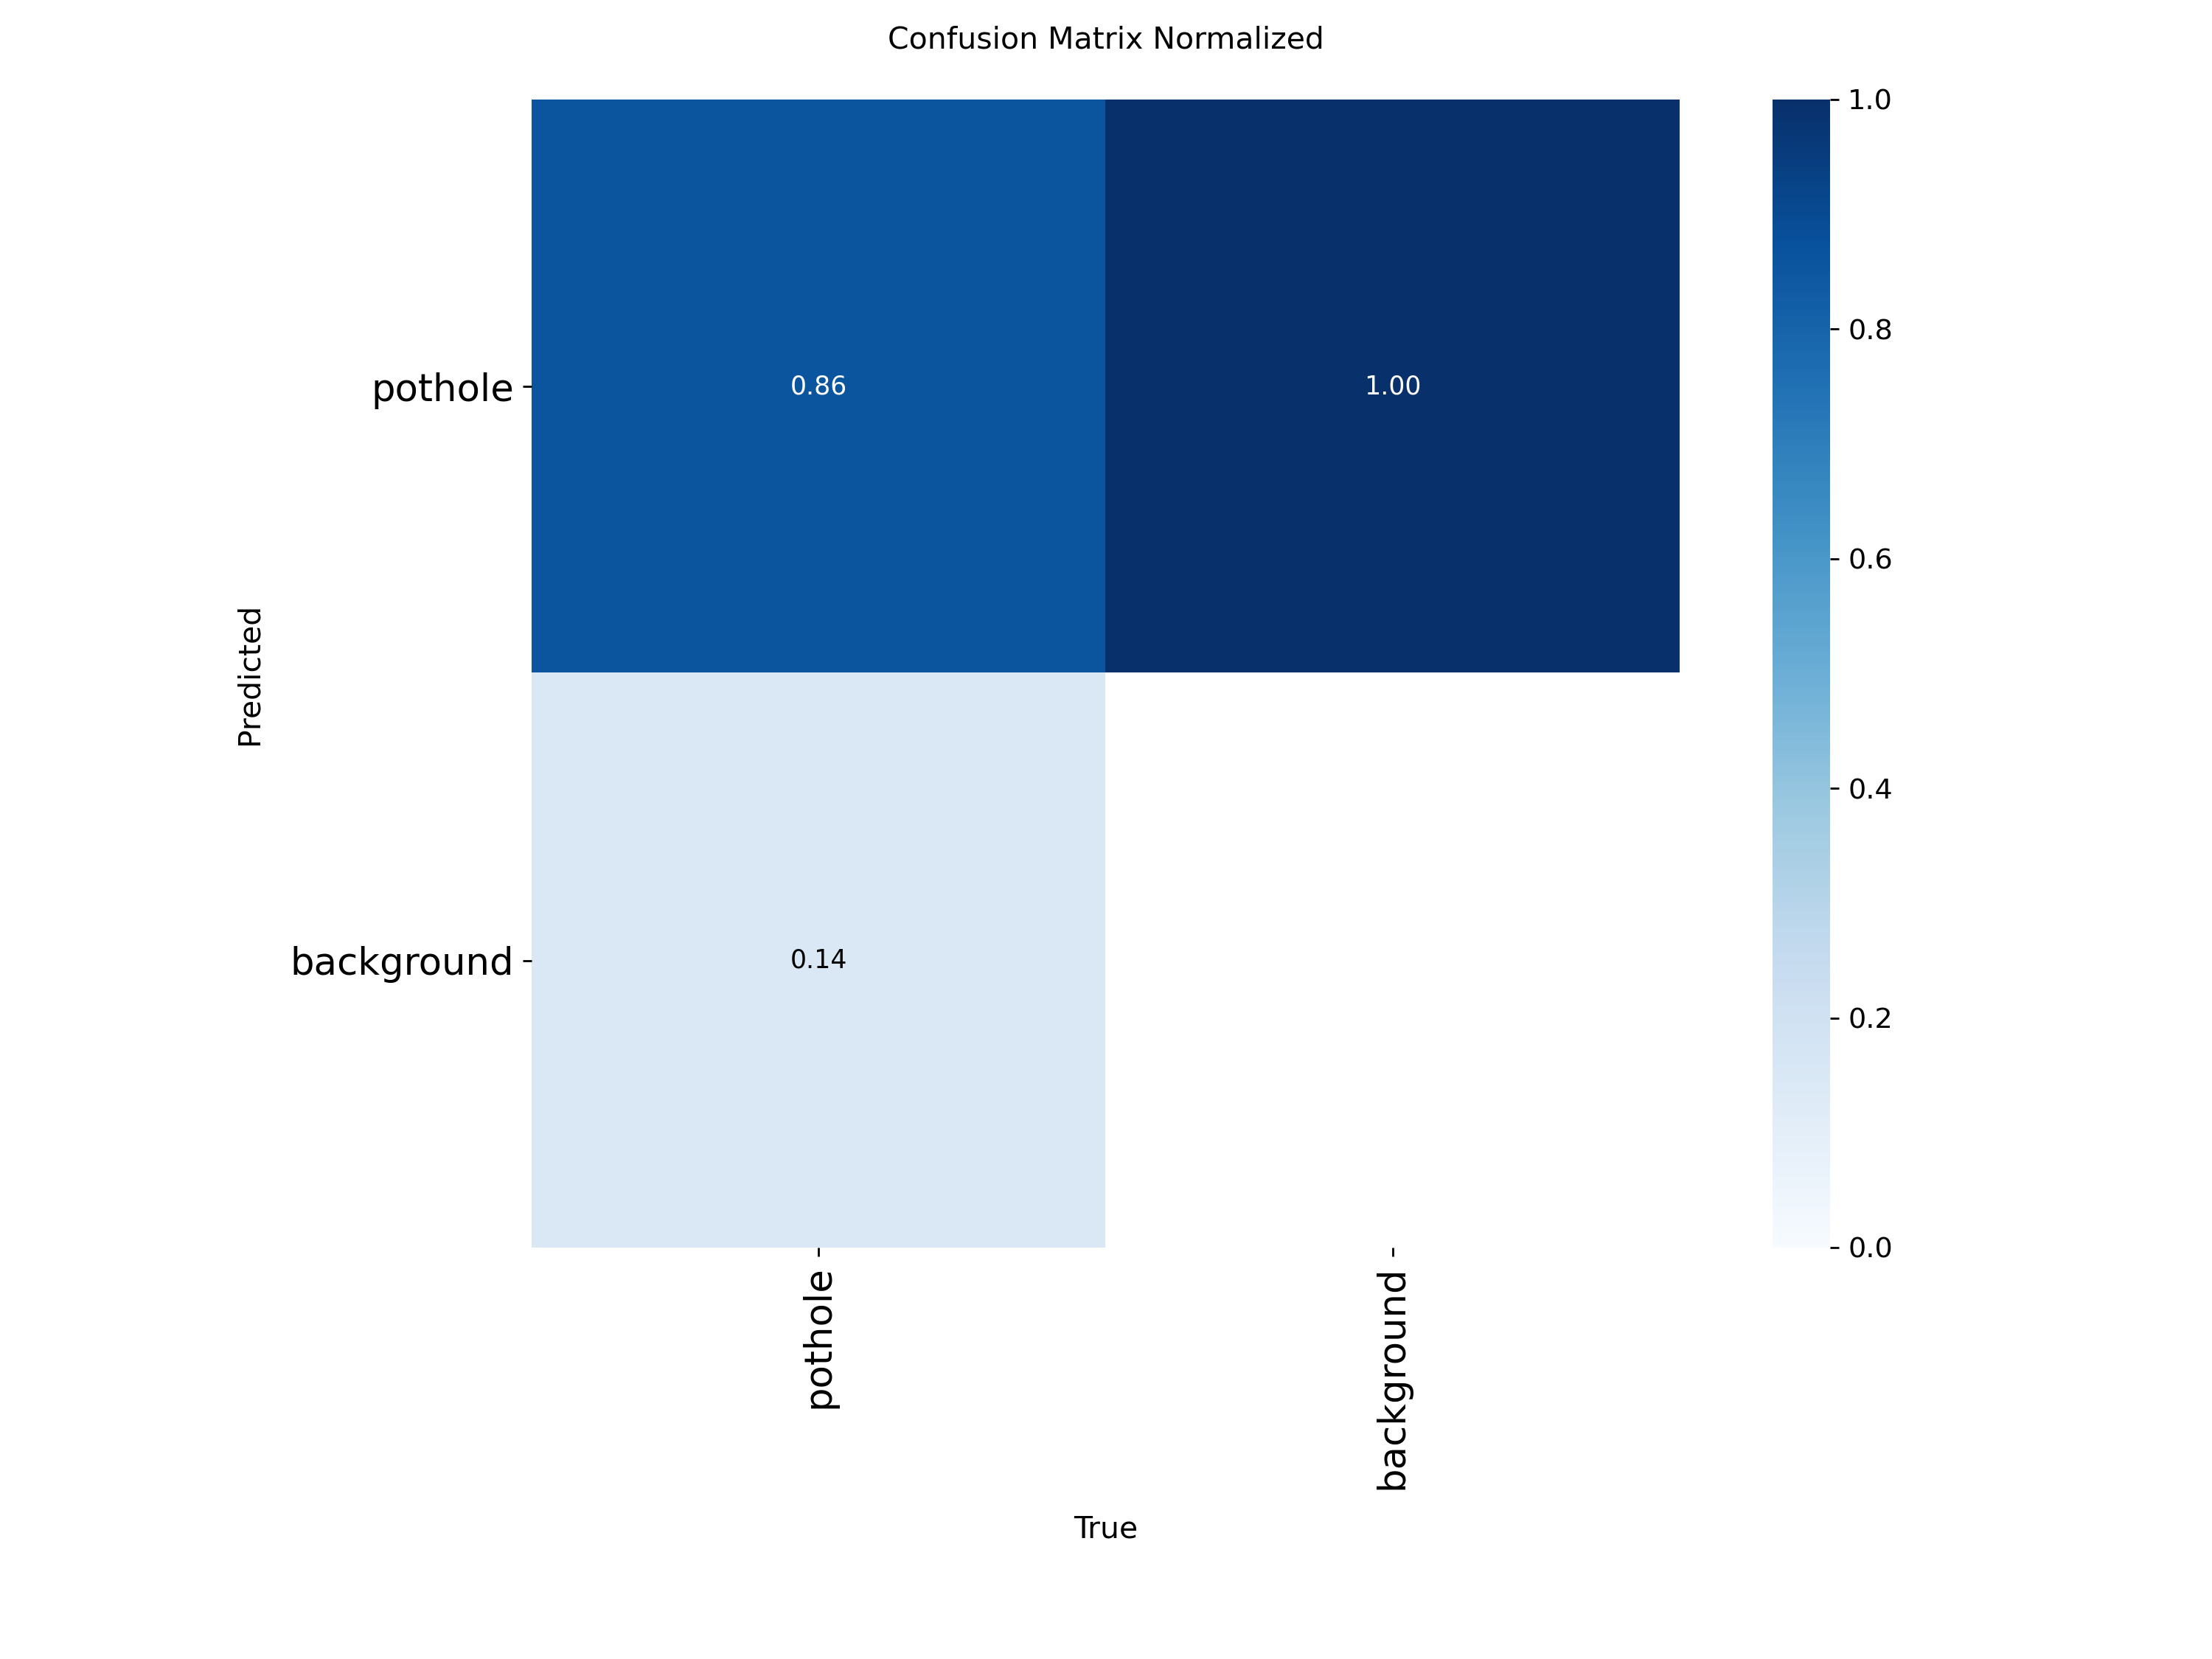


Ejemplo de Validación (Batch 0):


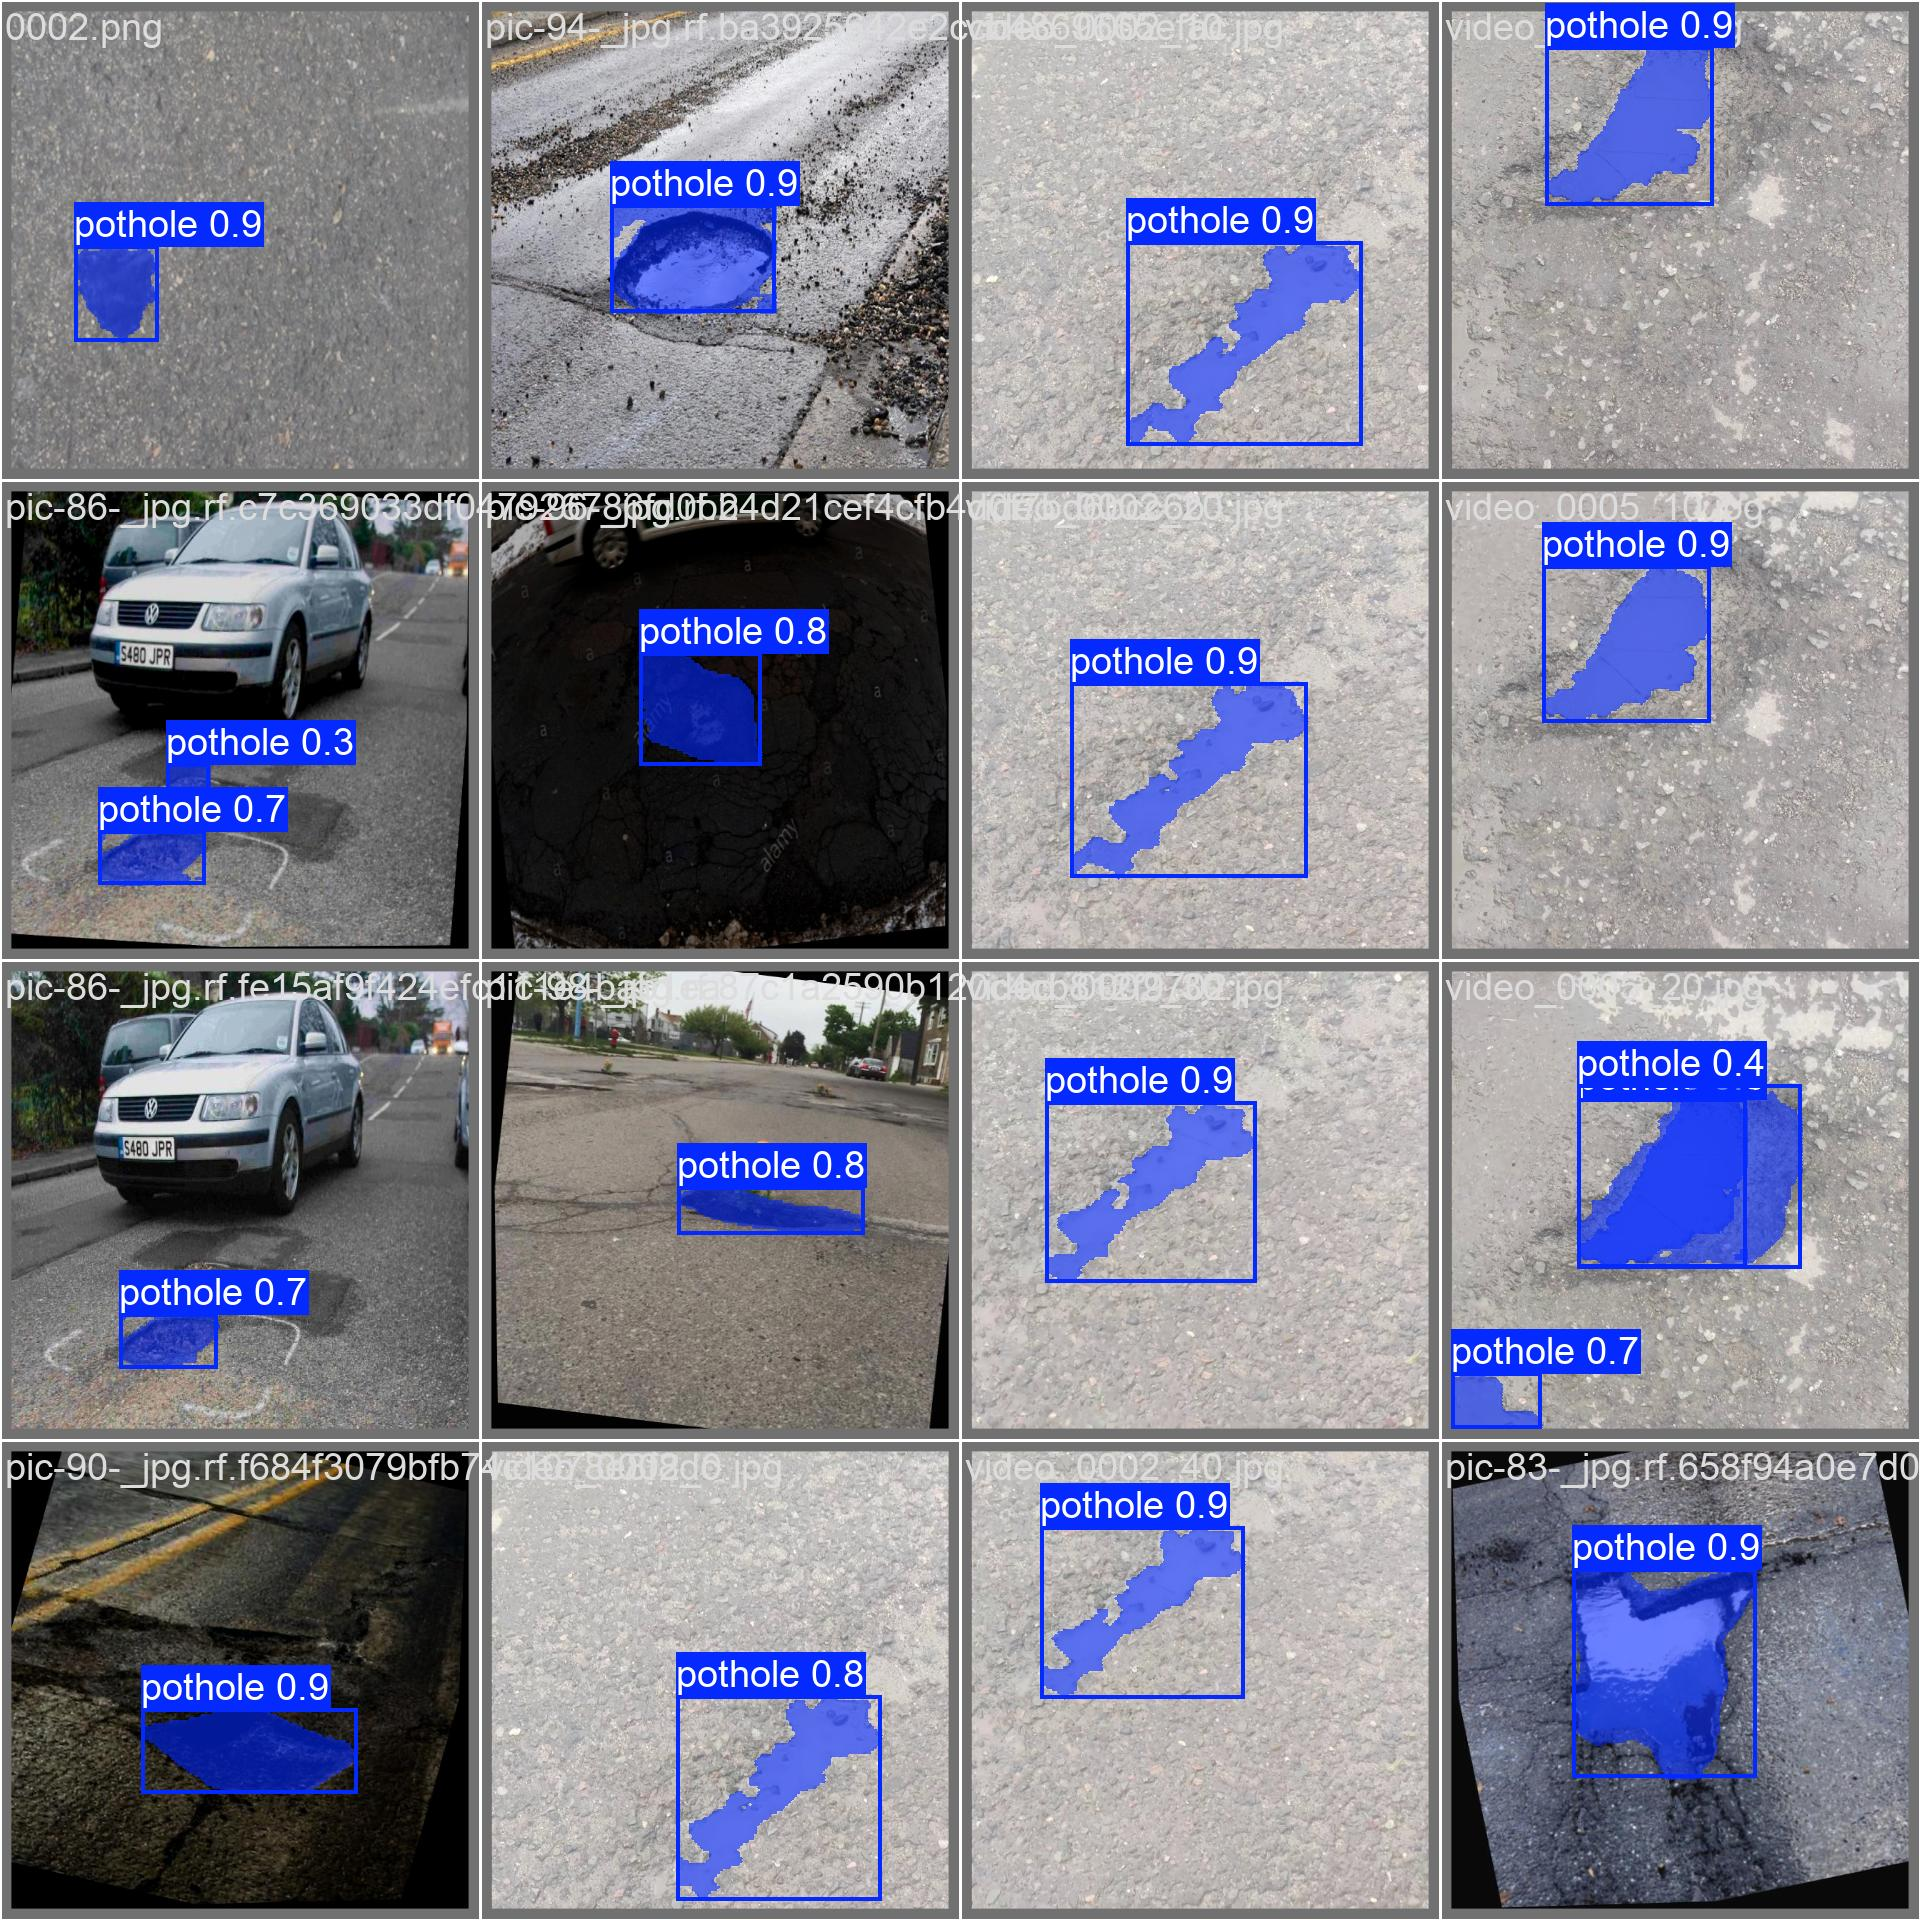

In [12]:

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

results_path = Path(f"{PROJECT_NAME}/{RUN_NAME}")
results_csv = results_path / "results.csv"

if results_csv.exists():
    # 1. Cargar Métricas
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    
    # 2. Encontrar Mejor Época (Segmentación)
    best_idx = df['metrics/mAP50-95(M)'].idxmax()
    best_epoch = df.iloc[best_idx]
    
    print("="*40)
    print(f" MEJOR EPOCA: {int(best_epoch['epoch'])}")
    print("="*40)
    print(f"mAP50 (Mask):    {best_epoch['metrics/mAP50(M)']:.4f}")
    print(f"mAP50-95 (Mask): {best_epoch['metrics/mAP50-95(M)']:.4f}")
    
    # Calcular F1 Score (Harmonic Mean de Precision y Recall)
    # Nota: YOLO guarda P y R de la época.
    p = best_epoch['metrics/precision(M)']
    r = best_epoch['metrics/recall(M)']
    f1 = 2 * (p * r) / (p + r + 1e-6)
    
    print(f"Precision (Mask): {p:.4f}")
    print(f"Recall (Mask):    {r:.4f}")
    print(f"F1 Score (Mask):  {f1:.4f}")
    print("-" * 40)

    # 3. Gráficas de Entrenamiento Personalizadas
    plt.figure(figsize=(18, 12))
    
    # Loss Box
    plt.subplot(2, 3, 1)
    plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    plt.title('Box Loss')
    plt.legend()
    plt.grid()

    # Loss Seg
    plt.subplot(2, 3, 2)
    plt.plot(df['epoch'], df['train/seg_loss'], label='Train Seg Loss')
    plt.plot(df['epoch'], df['val/seg_loss'], label='Val Seg Loss')
    plt.title('Segmentation Loss')
    plt.legend()
    plt.grid()

    # Metrics mAP
    plt.subplot(2, 3, 3)
    plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 Mask')
    plt.plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP50-95 Mask')
    plt.title('mAP Score')
    plt.legend()
    plt.grid()
    
    # Precision & Recall
    plt.subplot(2, 3, 4)
    plt.plot(df['epoch'], df['metrics/precision(M)'], label='Precision (M)', color='blue')
    plt.plot(df['epoch'], df['metrics/recall(M)'], label='Recall (M)', color='orange')
    plt.title('Precision & Recall')
    plt.legend()
    plt.grid()
    
    # F1 Estimado por época
    f1_curve = 2 * (df['metrics/precision(M)'] * df['metrics/recall(M)']) / (df['metrics/precision(M)'] + df['metrics/recall(M)'] + 1e-6)
    plt.subplot(2, 3, 5)
    plt.plot(df['epoch'], f1_curve, label='F1 Score Legacy', color='purple')
    plt.title('F1 Score (Approx Trend)')
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

    # 4. Mostrar Imágenes Generadas por YOLO (Más fiables)
    print("\nGráficas Oficiales de YOLO:")
    # Se añaden MaskP_curve, MaskR_curve, MaskPR_curve
    for img_name in ["results.png", "MaskP_curve.png", "MaskR_curve.png", "MaskPR_curve.png", "MaskF1_curve.png", "confusion_matrix_normalized.png"]:
        img_path = results_path / img_name
        if img_path.exists():
            print(f"--- {img_name} ---")
            display(Image(filename=img_path, width=640))
            
    # 5. Predicciones de Validación
    print("\nEjemplo de Validación (Batch 0):")
    val_pred = results_path / "val_batch0_pred.jpg"
    if val_pred.exists():
        display(Image(filename=val_pred, width=800))

else:
    print("No se encontraron resultados aún. Ejecute el entrenamiento primero.")



import shutil
import os
from pathlib import Path

# --- TU CÓDIGO DE ENTRENAMIENTO YA ESTÁ ARRIBA ---
# results = model.train(...) 

# -------------------------------------------------
# CÓDIGO PARA GUARDAR/COPIAR EL MODELO FINAL
# -------------------------------------------------

# 1. Definir dónde quieres guardar tu modelo final seguro
# Usando tu ruta del escritorio como referencia
ruta_destino_final = Path(r"C:\Users\Rayols\Desktop\Modelos_Entrenados")
ruta_destino_final.mkdir(parents=True, exist_ok=True) # Crea la carpeta si no existe

# 2. Localizar el archivo best.pt generado automáticamente
# Ultralytics guarda la ruta en: model.trainer.best
ruta_origen_modelo = Path(model.trainer.best)

# 3. Definir el nuevo nombre (puedes ponerle la fecha o versión)
nombre_final = "baches_yolov8_v1.pt"
ruta_completa_destino = ruta_destino_final / nombre_final

# 4. Copiar el archivo
print(f"⏳ Copiando modelo desde: {ruta_origen_modelo}")
print(f"📂 Hacia: {ruta_completa_destino}")

if ruta_origen_modelo.exists():
    shutil.copy2(ruta_origen_modelo, ruta_completa_destino)
    print(f"✅ ¡ÉXITO! Modelo guardado y seguro en: {ruta_completa_destino}")
else:
    print("⚠️ Error: No se encontró el archivo best.pt en la ruta de entrenamiento.")